In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# import lib_plot


from lib_equations import root_finder, herm_coeff, herm_func, trapezoidal, Simpson, Gauss_Leg


H_6(x) =  -120 + 720x^2 - 480x^4 + 64x^6


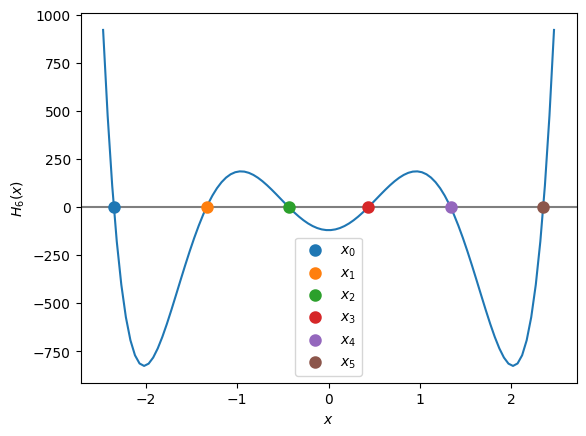

In [2]:
deg = 6
H_coeff = np.flip(herm_coeff(deg))
H_roots = root_finder(herm_coeff(deg))

coeffs = H_coeff
terms = []
for i, c in enumerate(coeffs):
    if np.isclose(c, 0):
        continue
    coeff = int(c) if np.isclose(c, round(c)) else float(c)
    sign = "+" if c > 0 else "-"
    abs_coeff = abs(coeff)
    if i == 0:
        term = f"{abs_coeff}"
    elif i == 1:
        term = f"{abs_coeff}x"
    else:
        term = f"{abs_coeff}x^{i}"
    if terms:
        terms.append(f" {sign} {term}")
    else:
        terms.append(f"{'-' if c < 0 else ''}{term}")
poly_str = "".join(terms) if terms else "0"
print(f'H_{deg}(x) = ', poly_str)

limx = max(H_roots)*1.05
xcoo = np.linspace(-limx, limx, 100, dtype=float)
ycoo = herm_func(xcoo, deg)

plt.plot(xcoo, ycoo)
for i, root in enumerate(H_roots):
    plt.scatter(root, 0, marker='o', zorder=3, lw=3, label=rf'$x_{i}$')

plt.axhline(color='black', alpha=0.5)
plt.ylim()

plt.xlabel(rf'$x$')
plt.ylabel(rf'$H_{deg}(x)$')
plt.legend()
plt.show()



In [3]:

from lib_equations import H_weigts, Gauss_Herm

func = lambda x: 1 / (1+x**2)

deg = 15
xcoo = root_finder(herm_coeff(deg))
ycoo = H_weigts(xcoo, deg)

res = Gauss_Herm(func, deg)
print(f'Result (n={deg}) = ', res)


Result (n=15) =  1.3435274681056917


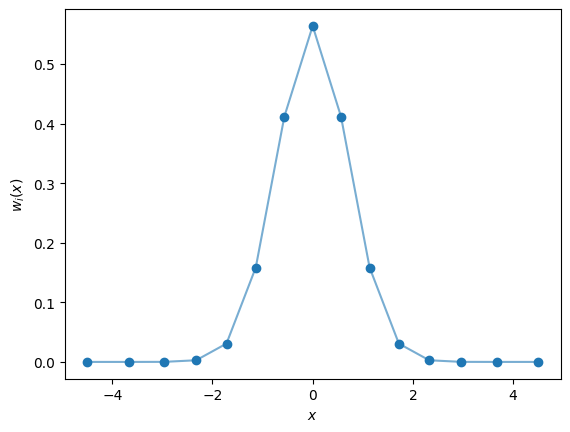

In [4]:

plt.plot(xcoo, ycoo, alpha=0.6)
plt.scatter(xcoo, ycoo, zorder=3, label='Radici ')
plt.xlabel(r'$x$')
plt.ylabel(rf'$w_i(x)$')
plt.show()


In [5]:
true = np.e * np.pi * math.erfc(1)

n_deg = np.arange(1, 21, 2)
errs_1 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_1.append(err)


n --> res:
    1  -->   1.7724538509055159
       -->   4.3e-01

    3  -->   1.417963080724429
       -->   7.5e-02

    5  -->   1.363426039158099
       -->   2.0e-02

    7  -->   1.3500262746455223
       -->   6.7e-03

    9  -->   1.3458700894018674
       -->   2.6e-03

    11 -->   1.3443774750608528
       -->   1.1e-03

    13 -->   1.343783187406804
       -->   4.9e-04

    15 -->   1.3435274681129077
       -->   2.3e-04

    17 -->   1.3434104959189417
       -->   1.2e-04

    19 -->   -0.0002480117854751666
       -->   1.3e+00



c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:525: RuntimeWarning: overflow encountered in scalar multiply
  num = 2**(n-1) * factorial(n-1) * np.sqrt(np.pi)


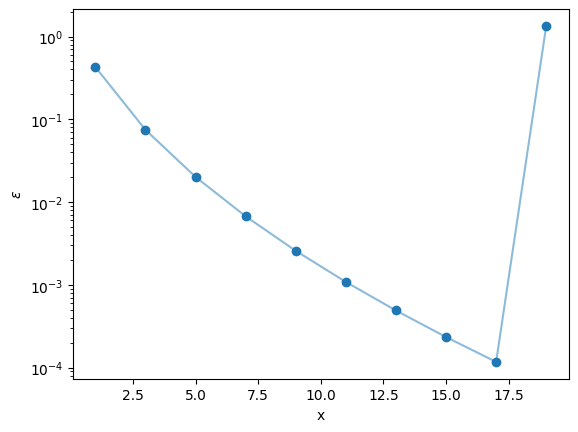

In [6]:
plt.plot(n_deg, errs_1, alpha=0.5)
plt.scatter(n_deg, errs_1)
plt.xlabel(rf'x')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')
plt.show()


n --> res:
    1  -->   0.0
       -->   5.8e+00

    3  -->   1.4955079367015296
       -->   4.3e+00

    5  -->   5.815864198283814
       -->   9.0e-14

    7  -->   5.815864198284941
       -->   1.2e-12

    9  -->   5.8158641982839905
       -->   2.7e-13

    11 -->   5.815864198286231
       -->   2.5e-12

    13 -->   5.81555101543874
       -->   3.1e-04

    15 -->   5.8158642024466864
       -->   4.2e-09

    17 -->   78.11084945642932
       -->   7.2e+01

    19 -->   -0.0010978961966874156
       -->   5.8e+00



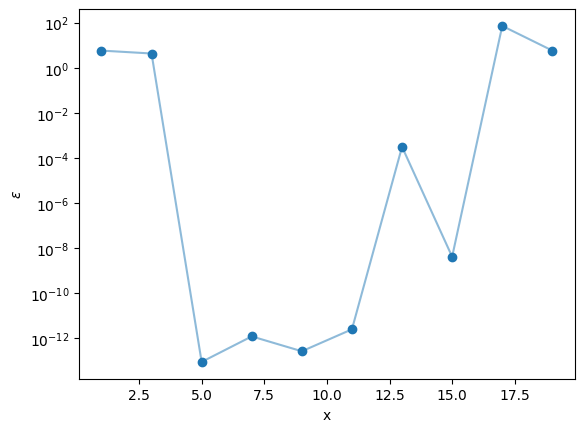

In [7]:
func = lambda x: 1/2 * x**8
true = 105/32 * np.sqrt(np.pi)

errs_2 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_2.append(err)

plt.plot(n_deg, errs_2, alpha=0.5)
plt.scatter(n_deg, errs_2)
plt.xlabel(rf'x')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')
plt.show()


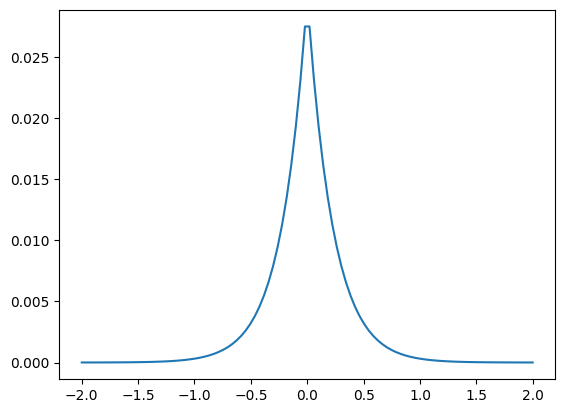

In [8]:
func = lambda x: (np.abs(x)+3)**5 * np.exp(-6*np.abs(x) - 9)
true = 101*np.exp(-9) / 2 

xmax = 2
xcoo = np.linspace(-xmax, xmax, 100)
ycoo = func(xcoo)

plt.plot(xcoo, ycoo)
# plt.yscale('log')
plt.show()


n --> res:
    1  -->   0.053153378345782105
       -->   4.7e-02

    3  -->   0.03549874033202752
       -->   2.9e-02

    5  -->   0.028648700010444873
       -->   2.2e-02

    7  -->   0.024935322919018232
       -->   1.9e-02

    9  -->   0.02259981224686321
       -->   1.6e-02

    11 -->   0.02099722084357723
       -->   1.5e-02

    13 -->   0.019829972718018674
       -->   1.4e-02

    15 -->   0.018942390320517644
       -->   1.3e-02

    17 -->   0.018244991543044563
       -->   1.2e-02

    19 -->   -3.2518288586160774e-06
       -->   6.2e-03



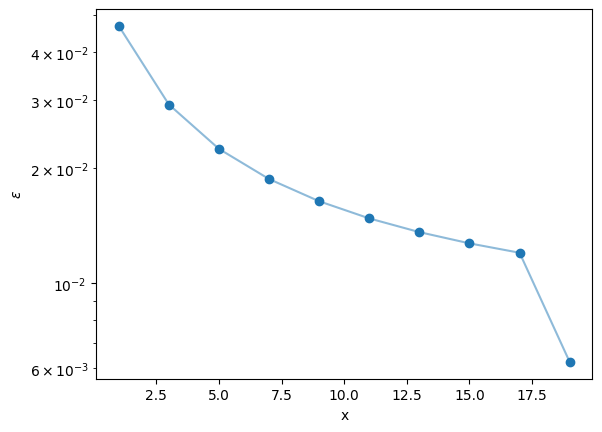

In [9]:

errs_3 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_3.append(err)

plt.plot(n_deg, errs_3, alpha=0.5)
plt.scatter(n_deg, errs_3)
plt.xlabel(rf'x')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')
plt.show()


dx = 4.0
dx = 1.3333333333333333
dx = 0.8
dx = 0.5714285714285714
dx = 0.4444444444444444
dx = 0.36363636363636365
dx = 0.3076923076923077
dx = 0.26666666666666666
dx = 0.23529411764705882
dx = 0.21052631578947367


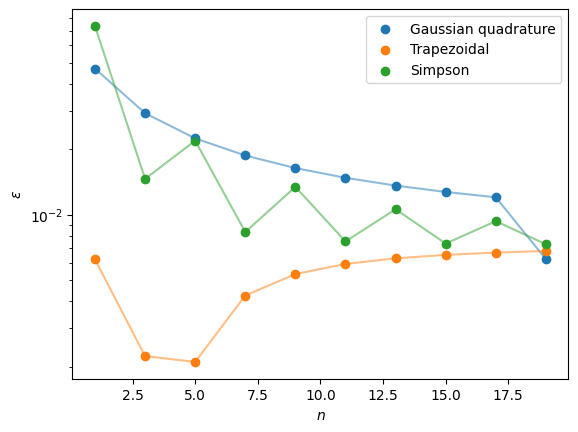

In [14]:

n_deg = np.arange(1, 21, 2)
errs_3_trap = []
errs_3_sim = []
for deg in n_deg:

    res = trapezoidal(func, -xmax, xmax, 2*xmax/ deg)
    print('dx =', 2*xmax/ deg)
    err = abs(res - true)
    errs_3_trap.append(err)
    
    res = Simpson(func, -xmax, xmax, 2*xmax/ deg)
    err = abs(res - true)
    errs_3_sim.append(err)

names = [
    'Gaussian quadrature',
    'Trapezoidal',
    'Simpson'
]

for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
    plt.plot(n_deg, ys, alpha=0.5)
    plt.scatter(n_deg, ys, label=names[n])
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')
plt.legend()
plt.show()
